When we define a LangGraph StateGraph, we use a state schema.

The state schema represents the structure and type of data that out graph will use

all nodes are expected to communicate with schema

LangGraph offers flexibility in how uou define your state schema, accordingly various types and validation approaches!

In [119]:
from typing_extensions import TypedDict
from typing import Literal

class TypedDictState(TypedDict):
    name: str
    game: Literal["cricket", "football", "hockey"]
    

In [120]:
def play_game(state: TypedDictState):
    print("--- Play Game node has been called ---")
    return {"name": state["name"]}

def cricket(state: TypedDictState):
    print("--- Cricket node has been called ---")
    return {"name": state["name"]}

def football(state: TypedDictState):
    print("--- Football node has been called ---")
    return {"name": state["name"]}

def badminton(state: TypedDictState):
    print("--- Badminton node has been called ---")
    return {"name": state["name"]}
    

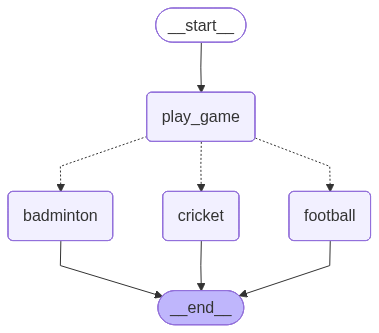

In [121]:
import random
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END


def random_play(state: TypedDictState) -> Literal['cricket', 'football', 'badminton']:
    name = state['name']

    if random.random() < 0.3:
        return 'cricket'
    elif random.random() < 0.6:
        return 'badminton'
    else:
        return 'football'
    
builder = StateGraph(TypedDictState)
builder.add_node("play_game", play_game)
builder.add_node("cricket", cricket)
builder.add_node("football", football)
builder.add_node("badminton", badminton)

builder.add_edge(START, "play_game")
builder.add_conditional_edges("play_game", random_play)
builder.add_edge("cricket", END)
builder.add_edge("football", END)
builder.add_edge("badminton", END)

graph_builder = builder.compile()


display(Image(graph_builder.get_graph().draw_mermaid_png()))


In [113]:
graph_builder.invoke({"name": "Deepak"})

--- Play Game node has been called ---
--- Football node has been called ---


{'name': 'Deepak wish to play  is playing football'}

In [122]:
graph_builder.invoke({"name": 1234})

--- Play Game node has been called ---
--- Football node has been called ---


{'name': 1234}

## Dataclasses
Python's dataclasses provide another way to define structured data.

Dataclasses offer a concise syntax for creating classes that are primarily used to store data.

In [126]:
### DataClasses 

from dataclasses import dataclass

@dataclass
class DataClassState:
    name: str
    game: Literal["cricket", "football", "hockey"]

 

In [127]:
def play_game(state: DataClassState):
    print("--- Play Game node has been called ---")
    return {"name": state.name + " is playing " }

def cricket(state: DataClassState):
    print("--- Cricket node has been called ---")
    return {"name": state.name + " is playing cricket"}

def football(state: DataClassState):
    print("--- Football node has been called ---")
    return {"name": state.name + " is playing football"}

def badminton(state: DataClassState):
    print("--- Badminton node has been called ---")
    return {"name": state.name + " is playing badminton"}
    

In [128]:
import random
def decide_play(state: DataClassState) -> Literal['cricket', 'football', 'badminton']:
    name = state.name

    if random.random() < 0.3:
        return 'cricket'
    elif random.random() < 0.6:
        return 'badminton'
    else:
        return 'football'

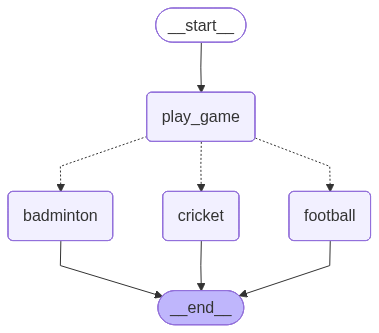

In [131]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
    
builder = StateGraph(DataClassState)
builder.add_node("play_game", play_game)
builder.add_node("cricket", cricket)
builder.add_node("football", football)
builder.add_node("badminton", badminton)

builder.add_edge(START, "play_game")
builder.add_conditional_edges("play_game", decide_play)
builder.add_edge("cricket", END)
builder.add_edge("football", END)
builder.add_edge("badminton", END)

graph = builder.compile()


display(Image(graph.get_graph().draw_mermaid_png()))


In [133]:
graph.invoke({"name": "Deepak", "game": "cricket"}) 

--- Play Game node has been called ---
--- Badminton node has been called ---


{'name': 'Deepak is playing  is playing badminton', 'game': 'cricket'}